Initial Data Preprocessing
------------------------------------------------

### The initial preprocessing steps 
- Remove duplicates if any
- Convert date columns to datetime format
- Ensure important numeric columns are numeric
- Drop non-informative identifier column
- Feature engineering from Gregorian transaction date
- Handle skewness in the target variable
- Encode categorical columns for machine learning models
- Final check for missing values after preprocessing


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
df = pd.read_csv("../dataset/Transactions_sale_for_real_estate_renamed.csv")
df.head()

,Region,City,City / District,Ref. Number of Transaction,Greg. Date of Transaction,Hijri Date of Transaction,Property Type,Number of Properties,Price,Area
0,منطقة مكة المكرمه,الطائف,الطائف/ حي البوادي,30416650,2025/07/01,1447/01/06,سكني,1,"240,000",630.00
1,منطقة مكة المكرمه,الطائف,الطائف/ الكدى,30417354,2025/07/01,1447/01/06,سكني,1,"1,000,000","1,652.36"
2,منطقة الرياض,الرياض,الرياض/الصحافة,30427896,2025/07/01,1447/01/06,تجاري,2,"63,000,000","1,800.00"
3,منطقة الرياض,الرياض,الرياض/بدر,30418087,2025/07/01,1447/01/06,تجاري,1,"2,415,000","1,050.00"
4,منطقة الرياض,الرياض,الرياض/الشفاء,30422608,2025/07/01,1447/01/06,سكني,1,"2,000,000",875.00


In [3]:
# 1) Remove duplicates if any
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().copy()

print("Duplicate rows before removal:", duplicates_before)
print("Shape after duplicate removal:", df.shape)

Duplicate rows before removal: 0
Shape after duplicate removal: (48820, 10)


In [4]:
# 2) Convert date columns to datetime format
# Coerce invalid values to NaT to avoid errors during preprocessing
date_cols = ["Greg. Date of Transaction", "Hijri Date of Transaction"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_cols].dtypes

Greg. Date of Transaction    datetime64[us]
Hijri Date of Transaction    datetime64[us]
dtype: object

In [5]:
df[["Greg. Date of Transaction", "Hijri Date of Transaction"]].head()

,Greg. Date of Transaction,Hijri Date of Transaction
0,2025-07-01,1447-01-06
1,2025-07-01,1447-01-06
2,2025-07-01,1447-01-06
3,2025-07-01,1447-01-06
4,2025-07-01,1447-01-06


In [7]:
# 3) Ensure important numeric columns are numeric
numeric_cols_to_fix = ["Price", "Area", "Number of Properties"]

for col in numeric_cols_to_fix:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[numeric_cols_to_fix].head())
print(df[numeric_cols_to_fix].dtypes)

      Price     Area  Number of Properties
0    240000   630.00                     1
1   1000000  1652.36                     1
2  63000000  1800.00                     2
3   2415000  1050.00                     1
4   2000000   875.00                     1
Price                     int64
Area                    float64
Number of Properties      int64
dtype: object


In [9]:
# 4) Drop non-informative identifier column
# Transaction reference number is an ID, not a meaningful predictive feature
cols_to_drop = ["Ref. Number of Transaction"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Columns after dropping ID column:")
print(df.columns.tolist())

Columns after dropping ID column:
['Region', 'City', 'City / District', 'Greg. Date of Transaction', 'Hijri Date of Transaction', 'Property Type', 'Number of Properties', 'Price', 'Area']


In [10]:
# 5) Feature engineering from Gregorian transaction date
# Extract simple time-based features that may be useful for future modeling
if "Greg. Date of Transaction" in df.columns:
    df["Transaction_Year"] = df["Greg. Date of Transaction"].dt.year
    df["Transaction_Month"] = df["Greg. Date of Transaction"].dt.month
    df["Transaction_Day"] = df["Greg. Date of Transaction"].dt.day

df[["Greg. Date of Transaction", "Transaction_Year", "Transaction_Month", "Transaction_Day"]].head()

,Greg. Date of Transaction,Transaction_Year,Transaction_Month,Transaction_Day
0,2025-07-01,2025,7,1
1,2025-07-01,2025,7,1
2,2025-07-01,2025,7,1
3,2025-07-01,2025,7,1
4,2025-07-01,2025,7,1


In [17]:
# 6) Handle skewness in the target variable
# Real estate prices are usually right-skewed, so log1p is commonly used
if "Price" in df.columns:
    df["Log_Price"] = np.log1p(df["Price"])

print(df[["Price", "Log_Price"]].head())

print("\nSkewness (Original):", df["Price"].skew())
print("Skewness (Log):", df["Log_Price"].skew())

      Price  Log_Price
0    240000  12.388398
1   1000000  13.815512
2  63000000  17.958645
3   2415000  14.697210
4   2000000  14.508658

Skewness (Original): 74.04234667776682
Skewness (Log): -0.49849647548383136


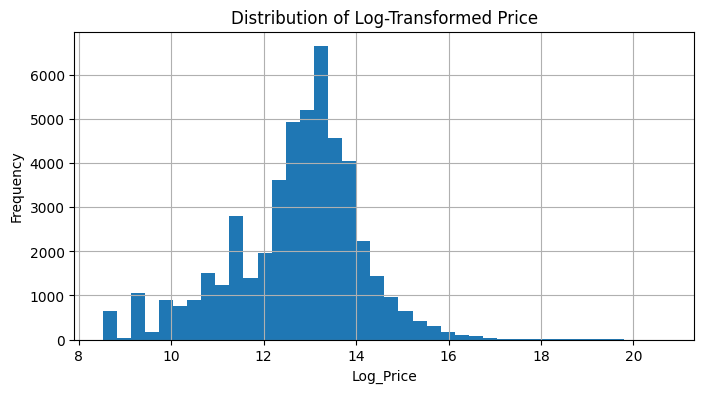

In [18]:
# Comparison of original vs transformed target distribution
plt.figure(figsize=(8, 4))
df["Log_Price"].hist(bins=40)
plt.title("Distribution of Log-Transformed Price")
plt.xlabel("Log_Price")
plt.ylabel("Frequency")
plt.show()

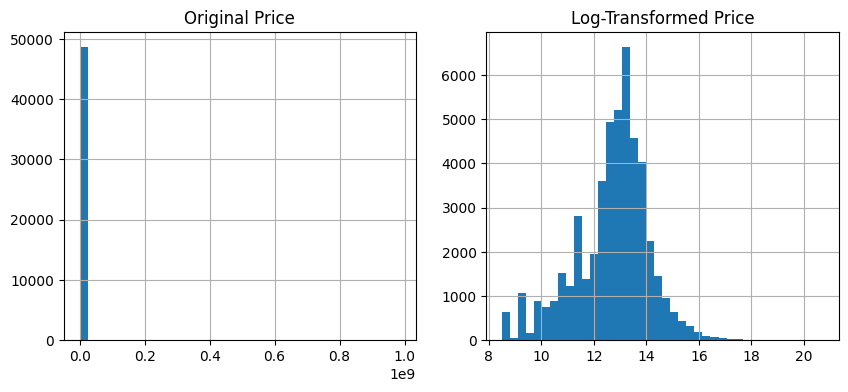

In [19]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
df["Price"].hist(bins=40)
plt.title("Original Price")

plt.subplot(1,2,2)
df["Log_Price"].hist(bins=40)
plt.title("Log-Transformed Price")

plt.show()

In [20]:
# 7) Encode categorical columns for machine learning models
categorical_cols_pre = df.select_dtypes(include=["object"]).columns.tolist()

# Drop the raw date columns after extracting useful date parts
date_cols_to_drop_for_model = [c for c in ["Greg. Date of Transaction", "Hijri Date of Transaction"] if c in df.columns]
df_model_base = df.drop(columns=date_cols_to_drop_for_model)

categorical_cols_pre = df_model_base.select_dtypes(include=["object"]).columns.tolist()
df_model_encoded = pd.get_dummies(df_model_base, columns=categorical_cols_pre, drop_first=True)

print("Categorical columns encoded:")
print(categorical_cols_pre)
print("\nEncoded dataset shape:", df_model_encoded.shape)

Categorical columns encoded:
['Region', 'City', 'City / District', 'Property Type']

Encoded dataset shape: (48820, 4527)


C:\Users\nadaf\AppData\Local\Temp\ipykernel_27544\2252544607.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_pre = df.select_dtypes(include=["object"]).columns.tolist()
C:\Users\nadaf\AppData\Local\Temp\ipykernel_27544\2252544607.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydat

In [23]:
# 8) Final check for missing values after preprocessing
print("Missing values after preprocessing:", df_model_encoded.isna().sum().sum())

Missing values after preprocessing: 0


In [24]:
# 9) Save preprocessing outputs for the next stage
df.to_csv("../dataset/Transactions_sale_for_real_estate_cleaned.csv", index=False)
df_model_encoded.to_csv("../dataset/Transactions_sale_for_real_estate_model_ready.csv", index=False)